In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# plt.style.use('dark_background')
import seaborn as sns

from sbi.inference import NPE
from sbi.analysis import pairplot
from sbi.utils import BoxUniform
from sbi.neural_nets import posterior_nn

import torch
torch.manual_seed(42) # no cambia mucho con la semilla, como ~2-3%

In [2]:
! ls /pscratch/sd/v/vtorresg/quijotes/Pk/matter/latin_hypercube/0

'Pk_m_z=0.5.txt'


In [3]:
pk0 = pd.read_csv('/pscratch/sd/v/vtorresg/quijotes/Pk/matter/latin_hypercube/0/Pk_m_z=0.5.txt', sep=r'\s+', header=None, names=['k', 'Pk'])
pk0

,k,Pk
0,0.008900,65442.344516
1,0.015079,60018.421190
2,0.021448,55823.741238
3,0.027837,28067.848171
4,0.034351,16094.621190
...,...,...
881,5.544583,96.466973
882,5.551739,86.888076
883,5.557493,86.335017
884,5.562282,101.723874


In [4]:
pp = pk0.to_numpy()
np.max(pp[:,0])

np.float64(5.5692727203231644)

In [5]:
path = Path('/pscratch/sd/v/vtorresg/quijotes/Pk/matter/latin_hypercube/')
files = sorted(path.rglob('Pk_m_z=0.5.txt'), key=lambda f: int(f.parent.name))
len(files)

2000

In [6]:
Pk_all = []
k_ref = None

for f in files:
    data = np.loadtxt(f)
    k = data[:, 0]
    pk = data[:, 1]

    if k_ref is None:
        k_ref = k
    else:
        assert np.allclose(k, k_ref), f'k grid differs in {f}'
    Pk_all.append(pk)

$$
x =
\begin{pmatrix}
P_0(k_1)&P_0(k_2)&\cdots\\
P_1(k_1)&P_1(k_2)&\cdots\\
\vdots&&\\
P_{1999}(k_1)&P_{1999}(k_2)&\cdots
\end{pmatrix}
$$

In [7]:
Pk_all = np.asarray(Pk_all, dtype=np.float32)
Pk_all.shape, k_ref.shape

((2000, 886), (886,))

In [8]:
kmin = 0.01
kmax = 0.5 #hasta aqui estaba haciendo fisher

mask = ((k_ref >= kmin) & (k_ref <= kmax))

k_use = k_ref[mask]
Pk_use = Pk_all[:, mask]
k_use.shape, Pk_use.shape

((78,), (2000, 78))

In [9]:
x_np = np.log10(Pk_use)

In [10]:
x = torch.tensor(x_np, dtype=torch.float32)
x.shape

torch.Size([2000, 78])

[Omega_m, Omega_b, h, n_s, sigma8]

In [11]:
params = np.loadtxt('/global/homes/v/vtorresg/quijotes-sbi/latin_hypercube_params.txt')
assert np.isfinite(params).all()

theta = torch.tensor(params, dtype=torch.float32)
theta.shape

torch.Size([2000, 5])

In [12]:
prior = BoxUniform(low=torch.tensor([0.1, 0.03, 0.5, 0.8, 0.6], dtype=torch.float32),
                                    high = torch.tensor([0.5, 0.07, 0.9, 1.2, 1.0], dtype=torch.float32))

In [13]:
assert theta.shape[0] == x.shape[0]
assert theta.shape[0] == 2000

In [14]:
rng = np.random.default_rng(42)
indices = rng.permutation(2000)

In [15]:
train_ids = indices[:1800]
test_ids = indices[1800:]

In [16]:
theta_train = theta[train_ids]
x_train = x[train_ids]

theta_test = theta[test_ids]
x_test = x[test_ids]

In [17]:
print(theta_train.shape)
print(x_train.shape)

print(torch.isfinite(x_train).all())
print(torch.isfinite(theta_train).all())

torch.Size([1800, 5])
torch.Size([1800, 78])
tensor(True)
tensor(True)


In [18]:
builder = posterior_nn(model='nsf',
                       hidden_features=128, #128 > 256 > 64 > 32
                       num_transforms=5,
                       z_score_x='independent',
                       z_score_theta='independent')

In [19]:
inference = NPE(prior=prior, density_estimator=builder,)

In [20]:
# density_estimator = (inference.append_simulations(theta_train, x_train).train())
density_estimator = inference.append_simulations(theta_train, x_train,).train(training_batch_size=128,
                                                                              learning_rate=5e-4,
                                                                              validation_fraction=0.1,
                                                                              stop_after_epochs=30,
                                                                              max_num_epochs=1000,
                                                                              show_train_summary=True)

 Neural network successfully converged after 217 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 217
        Best validation performance: -15.7779
        -------------------------
        


In [21]:
# samples = posterior.sample((50000,), x=x_obs)
posterior = inference.build_posterior(density_estimator)

In [22]:
n_test = len(x_test)
truth = theta_test.cpu().numpy()

In [23]:
means = np.zeros(truth.shape, dtype=np.float64)
stds = np.zeros_like(means)

In [24]:
low68 = np.zeros_like(means)
high68 = np.zeros_like(means)
low95 = np.zeros_like(means)
high95 = np.zeros_like(means)

In [25]:
# torch.manual_seed(43)

In [26]:
names = ['Omega_m', 'Omega_b', 'h', 'n_s', 'sigma8']

In [27]:
names_l = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']

In [28]:
n_test = len(x_test)
n_samples = 5000

In [29]:
truth = torch.as_tensor(theta_test).detach().cpu().numpy()

In [30]:
means = np.zeros_like(truth)
stds = np.zeros_like(truth)
low68 = np.zeros_like(truth)
high68 = np.zeros_like(truth)
low95 = np.zeros_like(truth)
high95 = np.zeros_like(truth)

In [31]:
for j in tqdm(range(n_test), desc='Eval cube'):
    samples_j = posterior.sample((n_samples,), x=x_test[j], show_progress_bars=False).detach().cpu().numpy()

    means[j] = samples_j.mean(axis=0)
    stds[j] = samples_j.std(axis=0, ddof=1)

    quantiles = np.quantile(samples_j, [0.025, 0.16, 0.84, 0.975], axis=0,)
    low95[j], low68[j], high68[j], high95[j] = quantiles

Eval cube:   0%|          | 0/200 [00:00<?, ?it/s]

/pscratch/sd/v/vtorresg/venvs/sbi/lib/python3.12/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2256.)
  outputs, _ = torch.triangular_solve(


In [32]:
errors = means - truth

In [33]:
inside68 = (truth >= low68) & (truth <= high68)
inside95 = (truth >= low95) & (truth <= high95)

In [34]:
summary = pd.DataFrame({'param': names,
                        'bias': errors.mean(axis=0),
                        'RMSE': np.sqrt((errors**2).mean(axis=0)),
                        'mean_posterior_std': stds.mean(axis=0),
                        'mean_68_interval_width': (high68 - low68).mean(axis=0),
                        'coverage_68': inside68.mean(axis=0),
                        'coverage_95': inside95.mean(axis=0)})
print(summary.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

  param    bias   RMSE  mean_posterior_std  mean_68_interval_width  coverage_68  coverage_95
Omega_m  0.0010 0.0243              0.0213                  0.0423       0.6350       0.9500
Omega_b  0.0003 0.0078              0.0079                  0.0166       0.6600       0.9450
      h  0.0032 0.0897              0.0904                  0.1992       0.6650       0.9400
    n_s -0.0021 0.0518              0.0496                  0.1019       0.7000       0.9450
 sigma8  0.0013 0.0071              0.0077                  0.0133       0.6500       0.9500


In [35]:
for i, name in enumerate(names):
    print(f'{name:8s} '
          f'true={truth[0, i]:.4f} '
          f'posterior={means[0, i]:.4f} ± {stds[0, i]:.4f}')

Omega_m  true=0.3863 posterior=0.3789 ± 0.0290
Omega_b  true=0.0470 posterior=0.0538 ± 0.0096
h        true=0.5973 posterior=0.6771 ± 0.1043
n_s      true=0.8945 posterior=0.8831 ± 0.0534
sigma8   true=0.6395 posterior=0.6363 ± 0.0059


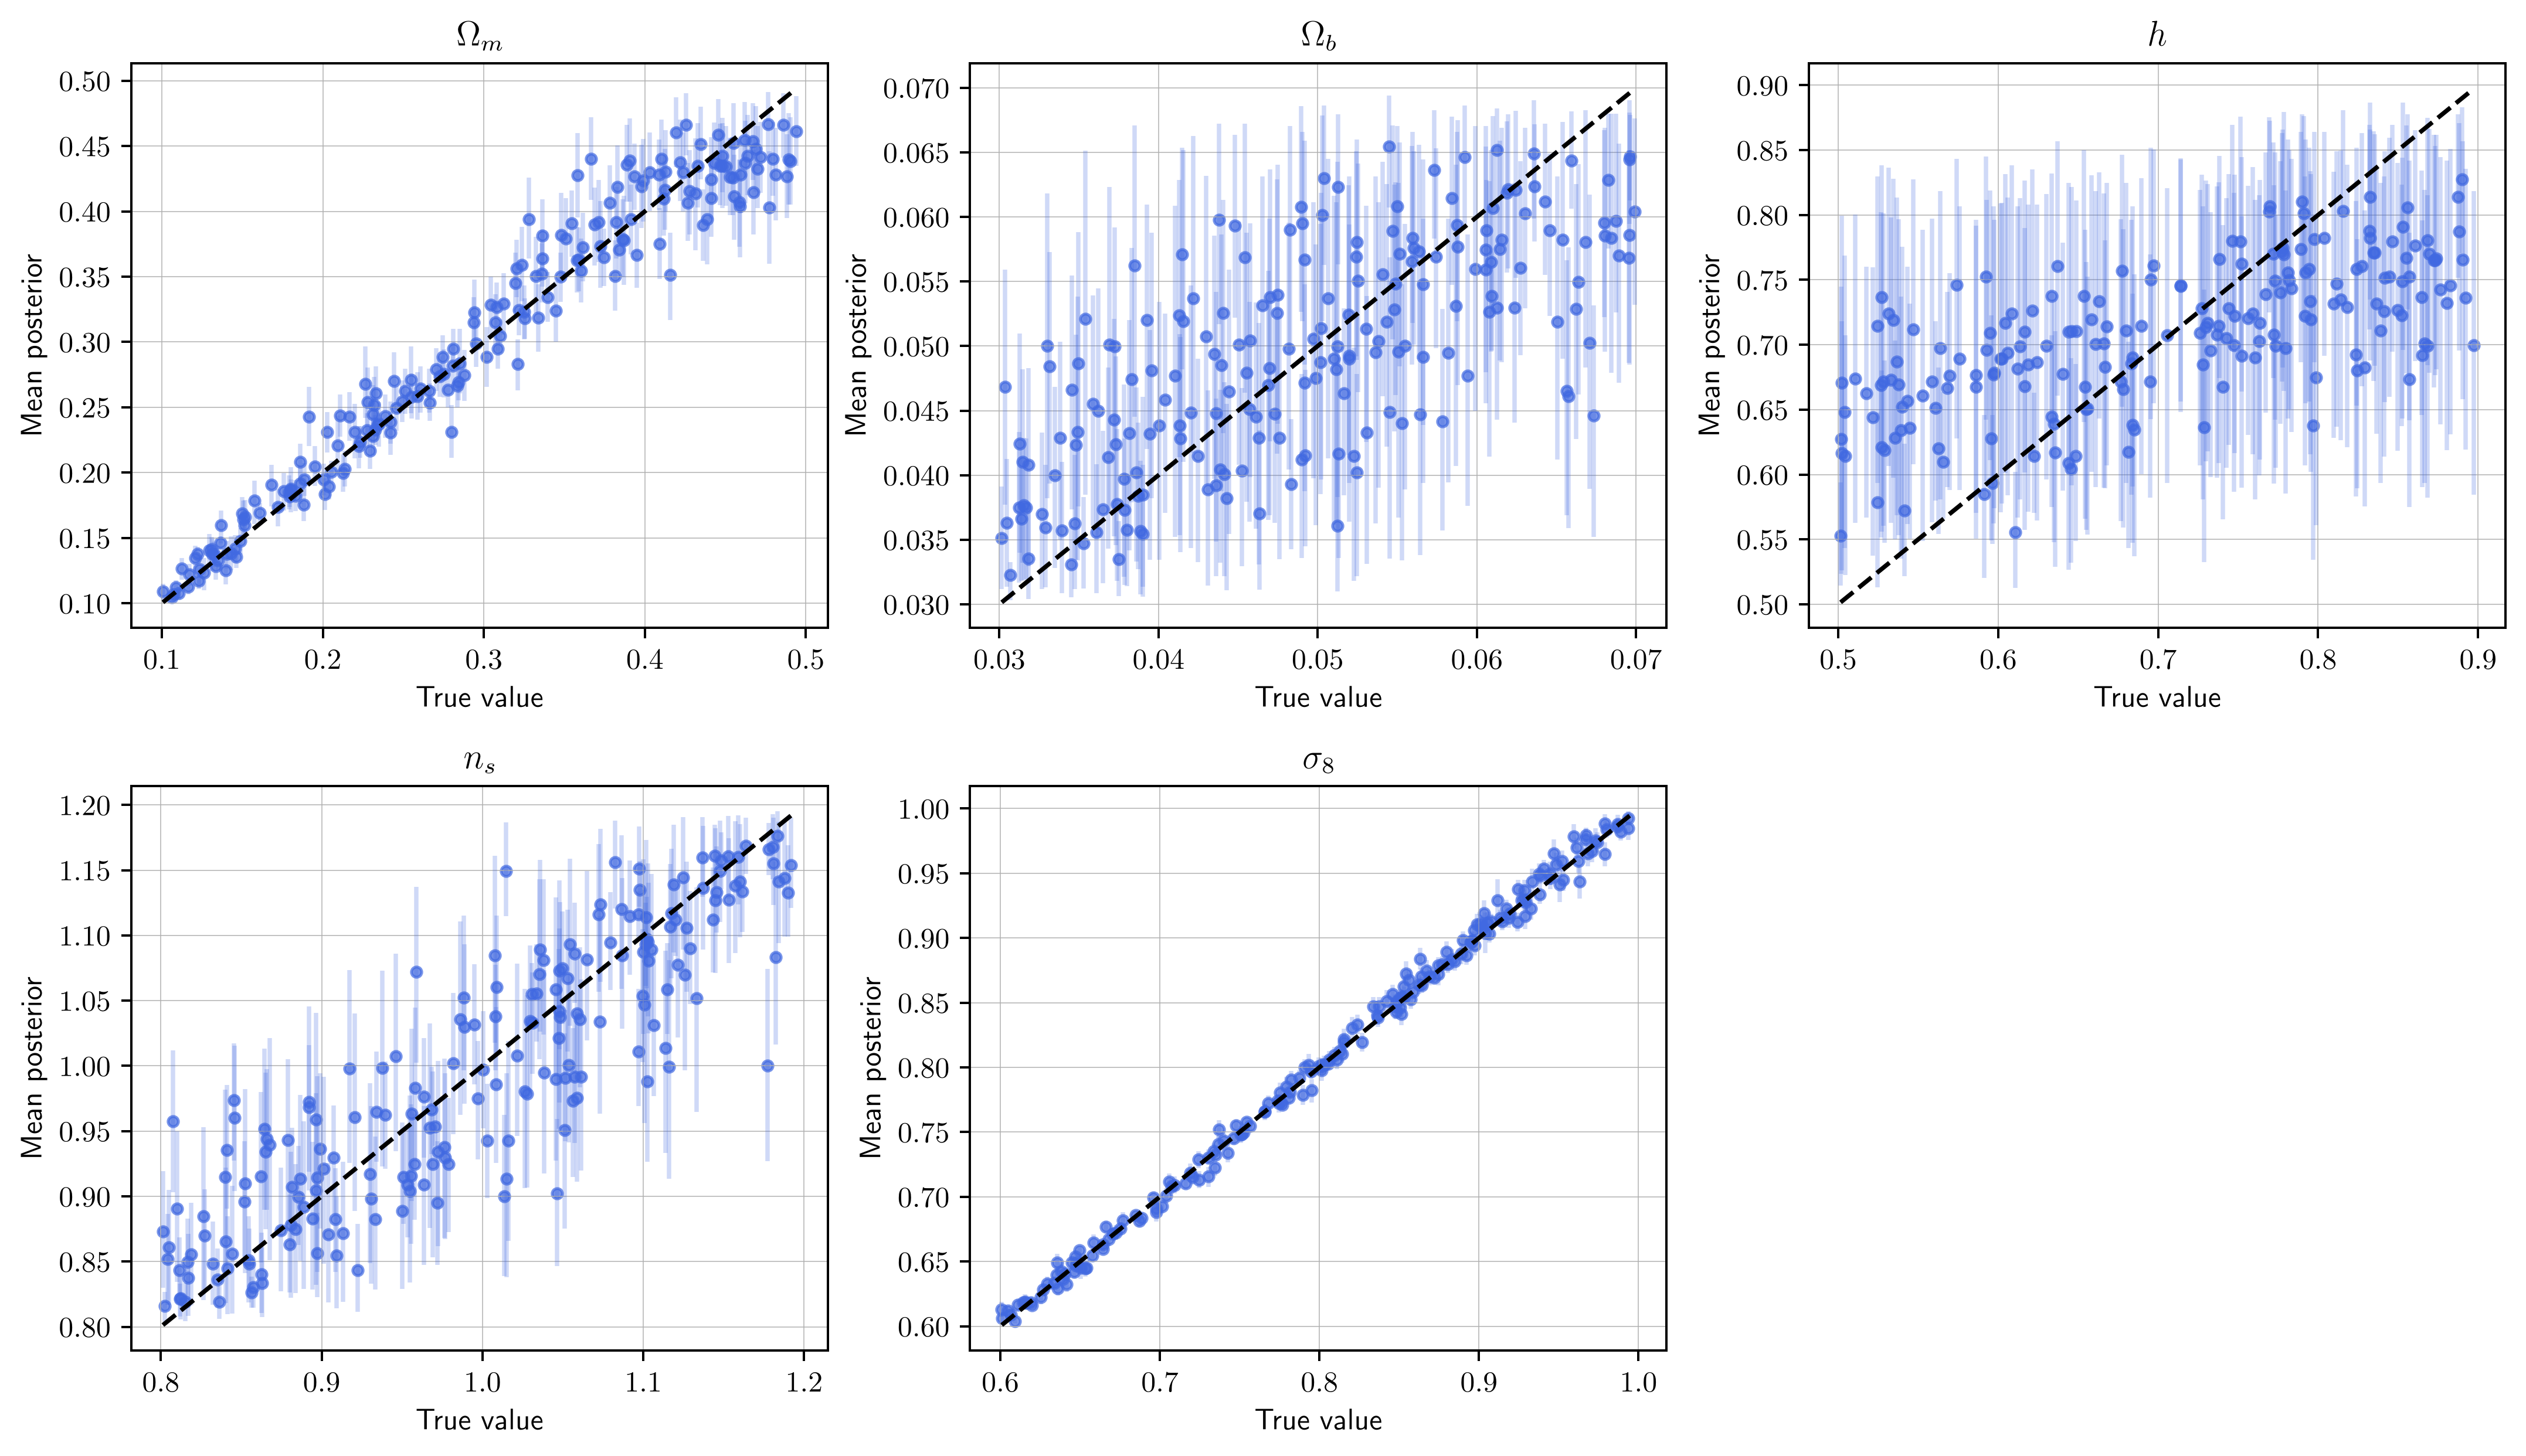

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), )
axes = axes.ravel()

for i, name in enumerate(names_l):
    ax = axes[i]
    
    ax.vlines(truth[:, i], low68[:, i], high68[:, i], color='royalblue', alpha=0.25)
    ax.scatter(truth[:, i], means[:, i], s=12, color='royalblue', alpha=0.7)

    limits = [min(truth[:, i].min(), low68[:, i].min(), means[:, i].min()),
              max(truth[:, i].max(), high68[:, i].max(), means[:, i].max())]
    ax.plot(limits, limits, '--', color='black')
    ax.set_xlabel('True value')
    ax.set_ylabel('Mean posterior')
    ax.set_title(names_l[i])
    ax.grid(lw=0.3)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [37]:
positions = np.arange(len(names))

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_624244/3346508066.py:4: SyntaxWarning: invalid escape sequence '\%'
  ax.bar(positions - 0.18, summary['coverage_68'], width=0.36, label='68\% interval', color='royalblue')
/tmp/ipykernel_624244/3346508066.py:5: SyntaxWarning: invalid escape sequence '\%'
  ax.bar(positions + 0.18, summary['coverage_95'], width=0.36, label='95\% interval', color='darkorange')


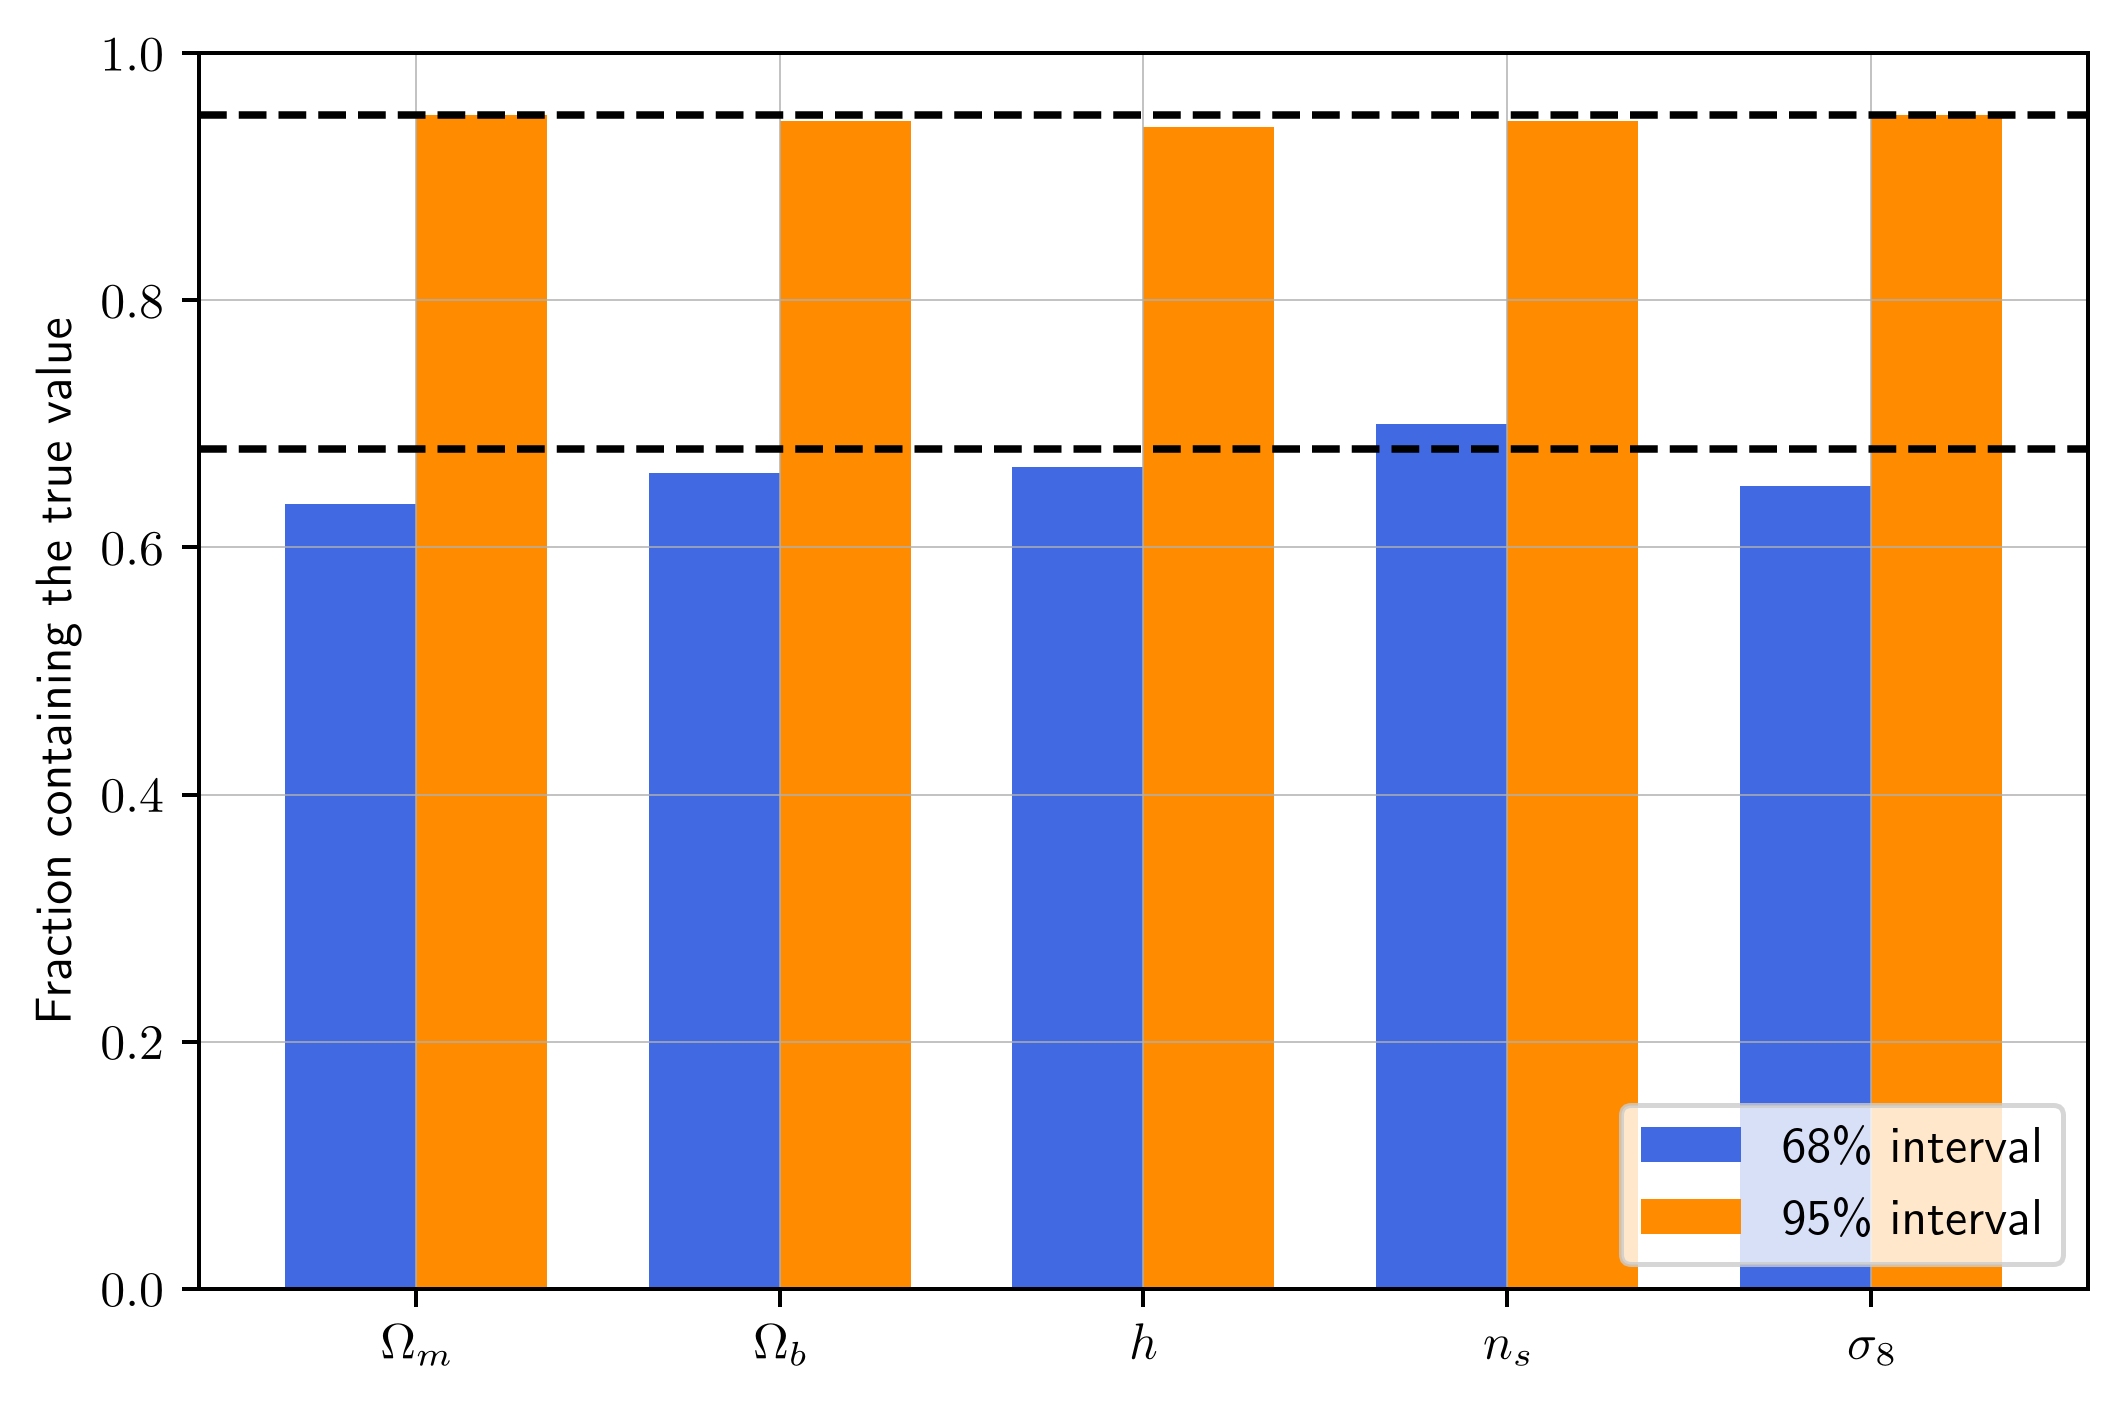

In [38]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.grid(lw=0.3)

ax.bar(positions - 0.18, summary['coverage_68'], width=0.36, label='68\% interval', color='royalblue')
ax.bar(positions + 0.18, summary['coverage_95'], width=0.36, label='95\% interval', color='darkorange')

ax.axhline(0.68, color='black', linestyle='--')
ax.axhline(0.95, color='black', linestyle='--')

ax.set_xticks(positions)
ax.set_xticklabels(names_l)
ax.set_ylabel('Fraction containing the true value')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [39]:
idx = 1
samples = posterior.sample((50_000,), x=x_test[idx], show_progress_bars=False).detach().cpu().numpy()

In [40]:
true_values = theta_test[idx].detach().cpu().numpy()
posterior_means = samples.mean(axis=0)

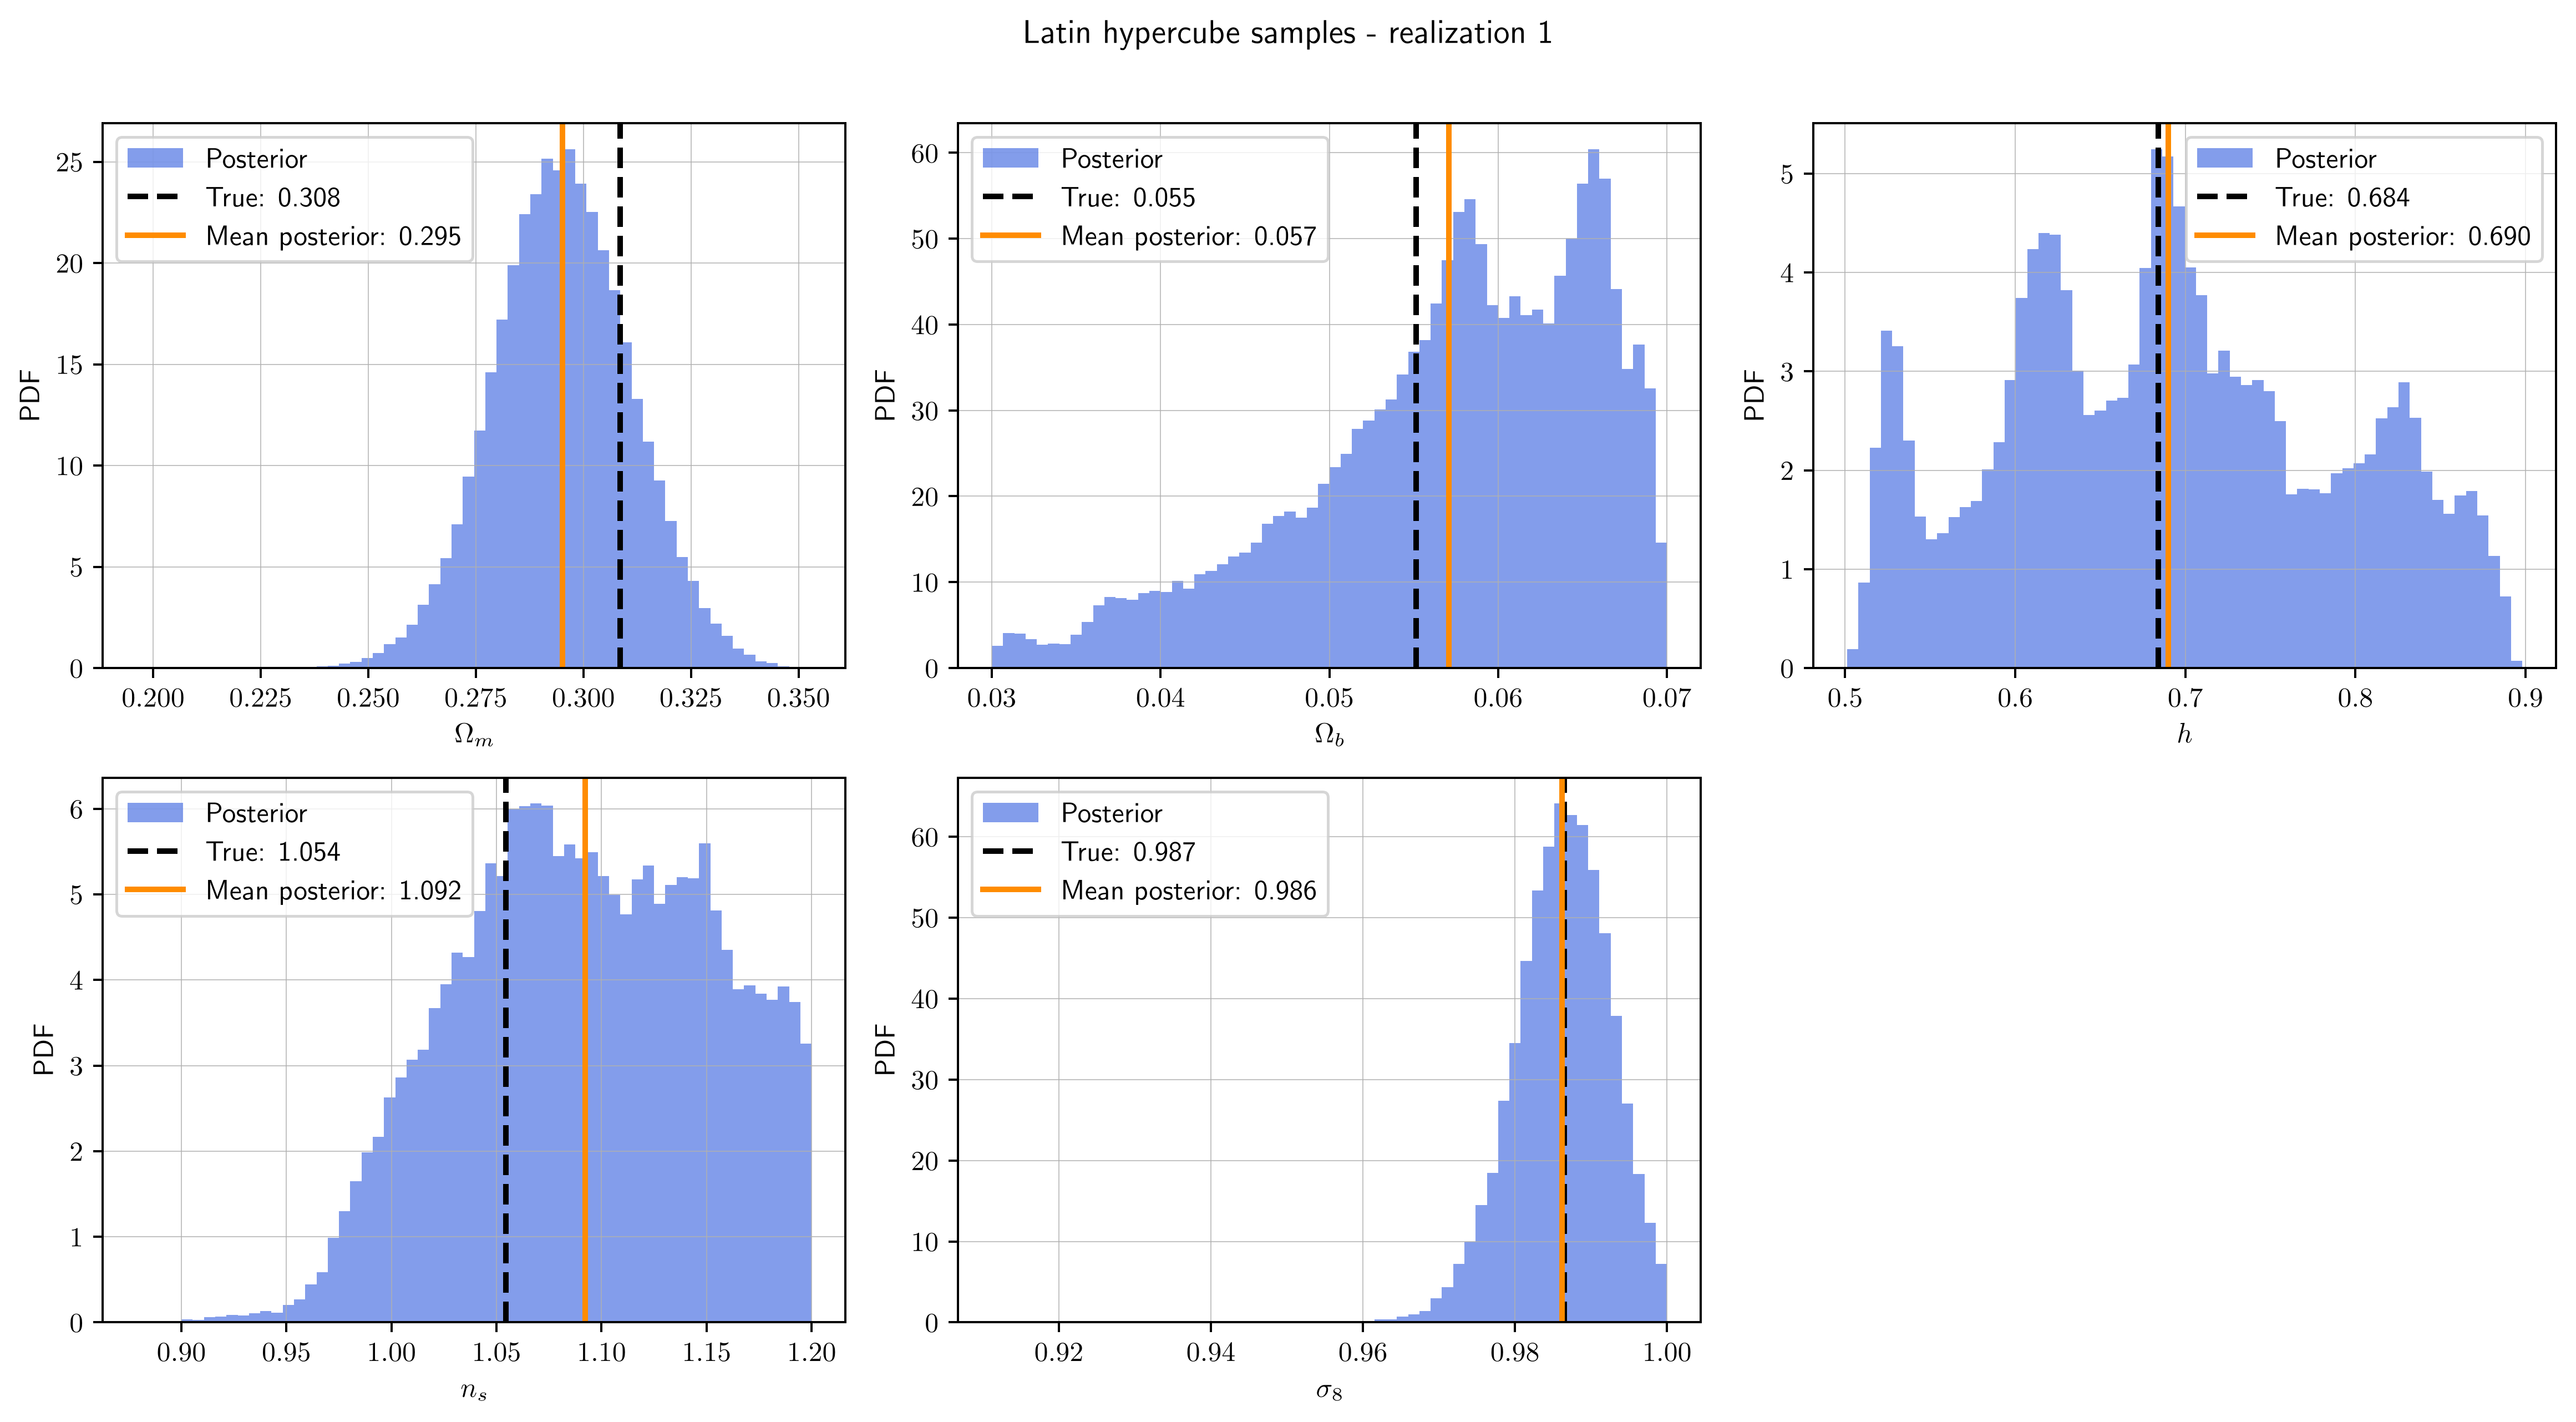

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

for j, label in enumerate(names_l):
    ax = axes[j]

    ax.hist(samples[:, j], bins=60, density=True, color='royalblue', alpha=0.65, label='Posterior')

    ax.axvline(true_values[j], color='black', linewidth=2, linestyle='--', label=f'True: {true_values[j]:.3f}')
    ax.axvline(posterior_means[j], color='darkorange', linewidth=2, label=f'Mean posterior: {posterior_means[j]:.3f}')

    ax.set_xlabel(label)
    ax.set_ylabel('PDF')
    ax.legend()
    ax.grid(lw=0.3)

fig.delaxes(axes[-1])
fig.suptitle(f'Latin hypercube samples - realization {idx}', y=1.01)
plt.tight_layout()
plt.show()